# Visió por Computador Examen Final 2026 Side #B

## Top-K Glow-Down

In this task, you will analyze the reconstruction error produced by Principal Component Analysis (PCA) when using a limited number of eigenfaces.

### Tasks:

1. Load all face images from the provided zip, resize them to a fixed size (e.g., 64×64) and convert them to grayscale.
2. Compute Eigenfaces (PCA) using **all images**.
3. **Randomly** select five face images for visualization.
4. Reconstruct the selected images using only the first  
   \( k in \{25, 50, 100\} \) eigenfaces.
5. Compute and visualize the **absolute reconstruction error** between the original and reconstructed images. Additionally, compute the median error per K value. Display one row per value of \(k\). Columns represent the selected random images + the median. The style and colormap of the plot should the ones showed in the reference.

### Hints:

1\) **Reconstruction** from the top-\(k\) eigenfaces can be written as:

X = X_mean + Z_k @ W_k

or obtained directly using the methods of  

`sklearn.decomposition.PCA`.

where  
- X_mean: mean face  
- Z_k: projection of images onto the first *k* principal components  
- W_k: matrix of the first *k* eigenfaces (principal components)
- @: matrix multiplication operator

2\) **Absolute reconstruction error** can be written as:

rec_error = np.abs(original_face - reconstructed_face)

as long as both original_face and reconstructed_face have the proper shape.

![Glow_Down](Top-K_Glow_Down_B.png)

En esta tarea, analizarás el **error de reconstrucción** producido por el **Análisis de Componentes Principales (PCA)** al usar un número limitado de **eigenfaces**.

### Tareas:

1. Carga todas las imágenes de rostros desde el zip proporcionado, redimensiónalas a un tamaño fijo (p. ej., 64×64) y conviértelas a escala de grises.
2. Calcula Eigenfaces (PCA) usando **todas las imágenes**.
3. Selecciona **aleatoriamente** cinco imágenes de rostros para visualización.
4. Reconstruye las imágenes seleccionadas usando solo las primeras  
   \( k in \{25, 50, 100\} \) eigenfaces.
5. Calcula y visualiza el **error absoluto de reconstrucción** entre las imágenes originales y las reconstruidas. Además, calcula el error mediano por cada valor de K. Muestra una fila por cada valor de \(k\). Las columnas representan las imágenes aleatorias seleccionadas + la mediana. El estilo y el mapa de color de la gráfica deben ser los mostrados en la referencia.

### Pistas:

1\) La **reconstrucción** a partir de las top-\(k\) eigenfaces puede escribirse como:

X = X_mean + Z_k @ W_k

o bien obtenerse directamente usando los métodos de  

`sklearn.decomposition.PCA`.

donde  
- X_mean: rostro medio  
- Z_k: proyección de las imágenes sobre los primeros *k* componentes principales  
- W_k: matriz de las primeras *k* eigenfaces (componentes principales)
- @: operador de multiplicación matricial

2\) El **error absoluto de reconstrucción** puede escribirse como:

rec_error = np.abs(original_face - reconstructed_face)

siempre que tanto original_face como reconstructed_face tengan la forma adecuada.

![Glow_Down](Top-K_Glow_Down_B.png)


In [12]:
# ----------------------------------------------------
# CONFIG
# ----------------------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
import random

IMAGE_DIR = "resources_B/faces"          # change to your folder path
IMG_SIZE = (64, 64)          # resize all images to same size
K_VALUES = [1, 25, 50]       # only these k's
RANDOM_SEED = 42
N_SHOW = 5
# ----------------------------------------------------

# Start here...

In [13]:
def ensure_gray(image):
    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = color.rgba2rgb(image)
        if image.shape[-1] == 3:
            return color.rgb2gray(image)
    return image


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import glob, os


# your code here
def absolut_reconstruction_error(folder= 'faces', num_test_faces=5):
    img_paths = sorted(glob.glob(os.path.join(folder,"*")))
    flatten_images = []
    for p in img_paths:
        if p != 'resources_B/faces\desktop.ini':
            img = io.imread(p)
            img = transform.resize(img, IMG_SIZE, anti_aliasing=True)
            img = ensure_gray(img)
            flatten_images.append(img.flatten())
    
    # split into a training and testing set
    X =np.array(flatten_images)
    
    X_train, X_test= train_test_split(X, test_size=0.3, random_state=RANDOM_SEED)

    pca_small = PCA(n_components=K_VALUES[0], svd_solver='randomized',
              whiten=True).fit(X)
    pca_medium = PCA(n_components=K_VALUES[1], svd_solver='randomized',
              whiten=True).fit(X)
    pca_large = PCA(n_components=K_VALUES[2], svd_solver='randomized',
              whiten=True).fit(X)
    
    X_subset = [X[random.randint(0, len(X))] for i in range(N_SHOW)]

    test_proj_small = pca_small.transform(X_subset)
    reconstruction_small = pca_small.inverse_transform(test_proj_small)
    
    test_proj_medium = pca_medium.transform(X_subset)
    reconstruction_medium = pca_medium.inverse_transform(test_proj_medium)
    
    test_proj_large = pca_large.transform(X_subset)
    reconstruction_large = pca_large.inverse_transform(test_proj_large)
    
    rec_error_small_images =[] 
    rec_error_medium_images = []
    rec_error_large_images =  []
    rec_error_median = []
    for i, foto_original in enumerate(X_subset):
        rec_error_small = abs(foto_original.reshape(IMG_SIZE)- reconstruction_small[i].reshape(IMG_SIZE))
        rec_error_small_images.append(rec_error_small)
        
        rec_error_medium = abs(foto_original.reshape(IMG_SIZE)- reconstruction_medium[i].reshape(IMG_SIZE))
        rec_error_medium_images.append(rec_error_medium)
        
        rec_error_large = abs(foto_original.reshape(IMG_SIZE)- reconstruction_large[i].reshape(IMG_SIZE))
        rec_error_large_images.append(rec_error_large)

    rec_error_median.append(np.median(rec_error_small_images, axis=0))
    rec_error_median.append(np.median(rec_error_medium_images, axis=0))
    rec_error_median.append(np.median(rec_error_large_images, axis=0))
    
    fig, ax = plt.subplots(3, num_test_faces + 1, figsize=(15, 6))

    for i in range(0,num_test_faces):
        
        ax[0,i].imshow(rec_error_small_images[i].reshape(IMG_SIZE), cmap='twilight_shifted')
        ax[0,i].set_title(f"Error (k={K_VALUES[0]})")
        ax[0,i].axis('off')

        ax[1,i].imshow(rec_error_medium_images[i].reshape(IMG_SIZE), cmap='twilight_shifted')
        ax[1,i].set_title(f"Error (k={K_VALUES[1]})")
        ax[1,i].axis('off')
        
        ax[2,i].imshow(rec_error_large_images[i].reshape(IMG_SIZE), cmap='twilight_shifted')
        ax[2,i].set_title(f"Error (k={K_VALUES[2]})")
        ax[2,i].axis('off')
        
    ax[0,5].imshow(rec_error_median[0].reshape(IMG_SIZE), cmap='twilight_shifted')
    ax[0,5].set_title(f"Median Error (k={K_VALUES[0]})")
    ax[0,5].axis('off')

    ax[1,5].imshow(rec_error_median[1].reshape(IMG_SIZE), cmap='twilight_shifted')
    ax[1,5].set_title(f"Median Error (k={K_VALUES[1]})")
    ax[1,5].axis('off')
    
    ax[2,5].imshow(rec_error_median[2].reshape(IMG_SIZE), cmap='twilight_shifted')
    ax[2,5].set_title(f"Median Error (k={K_VALUES[2]})")
    ax[2,5].axis('off')


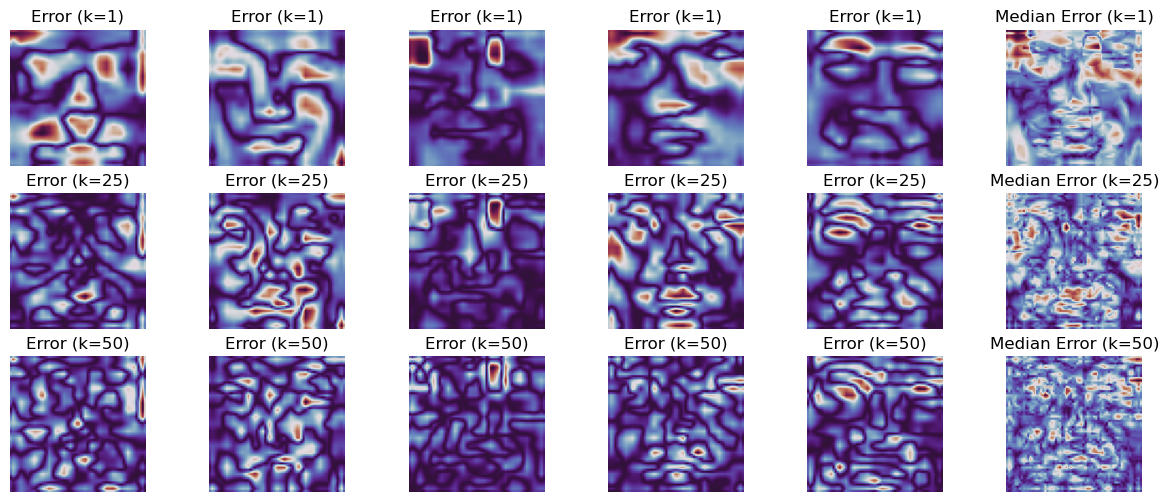

In [68]:
absolut_reconstruction_error(IMAGE_DIR, N_SHOW)

## Matchday


In this exercise, you will build a simple image search engine using the ORB (Oriented FAST and Rotated BRIEF) feature detector and descriptor. You will work with a folder containing several images. **One image will be randomly selected as the query**, and your tasks are the following.

### Tasks:


1.   **Extract ORB descriptors** from all images in the folder.
2.   Use descriptors to **measure similarity** between the query image and every other image.
3.   **Rank the images** by similarity.
4.   **Visualize top-3** most similar images.
5.   For every image visualized, **show the first 10 ORB keypoints**.

Style of the result should be the one shown in the following example.

![Matchday](Matchday_B.png)


### Hints:

- Do it step by step, first top-1 and then extend it for top-3.
- Do not leave the exercise blank, do as much as you know and present it properly.
- Use whatever distance suits you better but **specify it**.


En este ejercicio, construirás un motor de búsqueda de imágenes sencillo usando el detector y descriptor de características ORB (Oriented FAST and Rotated BRIEF). Trabajarás con una carpeta que contiene varias imágenes. **Una imagen se seleccionará aleatoriamente como consulta**, y tus tareas son las siguientes.

### Tareas:

1. **Extrae descriptores ORB** de todas las imágenes de la carpeta.
2. Usa los descriptores para **medir la similitud** entre la imagen de consulta y cada una de las demás imágenes.
3. **Ordena las imágenes** por similitud.
4. **Visualiza el top-3** de las imágenes más similares.
5. Para cada imagen visualizada, **muestra los primeros 10 puntos clave (keypoints) ORB**.

El estilo del resultado debe ser el mostrado en el siguiente ejemplo.

![Matchday](Matchday_B.png)

### Pistas:

- Hazlo paso a paso: primero top-1 y luego extiéndelo a top-3.
- No dejes el ejercicio en blanco; haz tanto como sepas y preséntalo correctamente.
- Usa la distancia que mejor te convenga, pero **especifícala**.


In [40]:
# Start here...
# En este ejercicio haremos uso de la distancia euclidiana



In [41]:
import glob
import os
from skimage.feature import match_descriptors, ORB
import numpy as np
from skimage import io, color, transform, feature, measure
import matplotlib.pyplot as plt




def ensure_gray(image):
    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = color.rgba2rgb(image)
        if image.shape[-1] == 3:
            return color.rgb2gray(image)
    return image


In [59]:
def get_ORB(image, n_keypoints=1000, fast_threshold=0.08):

    if image.ndim == 3:
        image = color.rgb2gray(image)
    orb = ORB(n_keypoints=n_keypoints, fast_threshold=fast_threshold)
    orb.detect_and_extract(image)
    # orb.keypoints are (row, col), orb.descriptors are binary
    return orb.keypoints, orb.descriptors

def match_orb_images(model_path, folder ='resources_B/images',
                     n_keypoints=1000,
                     fast_threshold=0.08,
                     max_ratio=0.8,
                     cross_check=False,
                     plot_top=100, top_n = 3):

    # read and prepare images
    model = io.imread(model_path) if isinstance(model_path, str) else model_path

    # ensure grayscale for ORB
    model_g = ensure_gray(model)
    

     # --- 2. ITERAR Y GUARDAR TODOS LOS CANDIDATOS ---
    paths = sorted(glob.glob(os.path.join(folder, "*")))
    paths = [p for p in paths]
    
    # detect ORB keypoints & descriptors
    kp1, desc1 = get_ORB(model_g, n_keypoints=n_keypoints, fast_threshold=fast_threshold)
        
    all_candidates = [] # <--- Aquí guardaremos diccionarios

    for p in paths:
        # Cargar y procesar candidato
        im = io.imread(p)
        img_proc = ensure_gray(im) # <--- La imagen que querías guardar

        # SIFT Candidato
        orb_i = ORB(n_keypoints=n_keypoints, fast_threshold=fast_threshold)
        orb_i.detect_and_extract(img_proc)
        desc_i = orb_i.descriptors
        kp_i = orb_i.keypoints

        # Matching
        if desc1 is None or desc_i is None or len(desc1)==0 or len(desc_i)==0:
            cnt = 0
            matches = np.zeros((0,2), dtype=int)
        else:
            matches = match_descriptors(desc1, desc_i, cross_check=cross_check,
                                max_ratio=max_ratio,
                                metric='hamming')
            cnt = matches.shape[0]

        # Guardamos un diccionario completo en la lista
        candidate_data = {
            'count': cnt,
            'path': p,
            'image_processed': img_proc, # <--- Guardamos la imagen procesada como pediste
            'keypoints': kp_i,
            'descriptors': desc_i,
            'matches': matches
        }
        all_candidates.append(candidate_data)


 # --- 3. ORDENAR Y SELECCIONAR TOP N ---
    # Ordenamos la lista de diccionarios basándonos en la clave 'count'
    # reverse=True para que sea de mayor a menor
    
    sorted_candidates = sorted(all_candidates, key=lambda x: x['count'], reverse=True)
    
    # Nos quedamos con los N primeros
    top_candidates = sorted_candidates[:top_n]

    if not top_candidates:
        print("No matches found.")
        return None

    # --- 4. VISUALIZAR LOS TOP N ---
    # Creamos subplots dinámicos según el número de top_n
    fig, ax = plt.subplots(2, 2, figsize=(15, 5))
    img_cand = top_candidates[0]['image_processed']
    kp_cand = top_candidates[0]['keypoints'][:10]
    ax[0,0].imshow(img_cand, cmap='gray')
    ax[0,0].scatter(kp_cand[:, 1], kp_cand[:, 0], 
                  s=8,          # Tamaño del punto
                  c='red',       # Color
                  marker='x')    # Forma de estrella (o '.' para punto)
    ax[0,0].set_title(f"ORB Query\n {os.path.basename(top_candidates[0]['path'])}")
    ax[0,0].axis('off')

    
    img_cand = top_candidates[0]['image_processed']
    kp_cand = top_candidates[0]['keypoints'][:10]
    
    ax[0,1].imshow(img_cand, cmap='gray')

    # 2. AHORA haz el scatter de los keypoints
    # kp_cand[:, 1] son las X (columnas)
    # kp_cand[:, 0] son las Y (filas)
    ax[0,1].scatter(kp_cand[:, 1], kp_cand[:, 0], 
                  s=8,          # Tamaño del punto
                  c='red',       # Color
                  marker='x')    # Forma de estrella (o '.' para punto)
    ax[0,1].set_title(f"ORB Rank 1\n {os.path.basename(top_candidates[0]['path'])}")
    ax[0,1].axis('off')
    
    img_cand = top_candidates[1]['image_processed']
    kp_cand = top_candidates[1]['keypoints'][:10]
    
    ax[1,0].imshow(img_cand, cmap='gray')

    # 2. AHORA haz el scatter de los keypoints
    # kp_cand[:, 1] son las X (columnas)
    # kp_cand[:, 0] son las Y (filas)
    ax[1,0].scatter(kp_cand[:, 1], kp_cand[:, 0], 
                  s=8,          # Tamaño del punto
                  c='red',       # Color
                  marker='x')    # Forma de estrella (o '.' para punto)
    ax[1,0].set_title(f"ORB Rank 2\n {os.path.basename(top_candidates[1]['path'])}")
    ax[1,0].axis('off')    
    
    
    img_cand = top_candidates[2]['image_processed']
    kp_cand = top_candidates[2]['keypoints'][:10]
    
    ax[1,1].imshow(img_cand, cmap='gray')

    # 2. AHORA haz el scatter de los keypoints
    # kp_cand[:, 1] son las X (columnas)
    # kp_cand[:, 0] son las Y (filas)
    ax[1,1].scatter(kp_cand[:, 1], kp_cand[:, 0], 
                  s=8,          # Tamaño del punto
                  c='red',       # Color
                  marker='x')    # Forma de estrella (o '.' para punto)
    ax[1,1].set_title(f"ORB Rank 3\n {os.path.basename(top_candidates[2]['path'])}")
    ax[1,1].axis('off')  
    


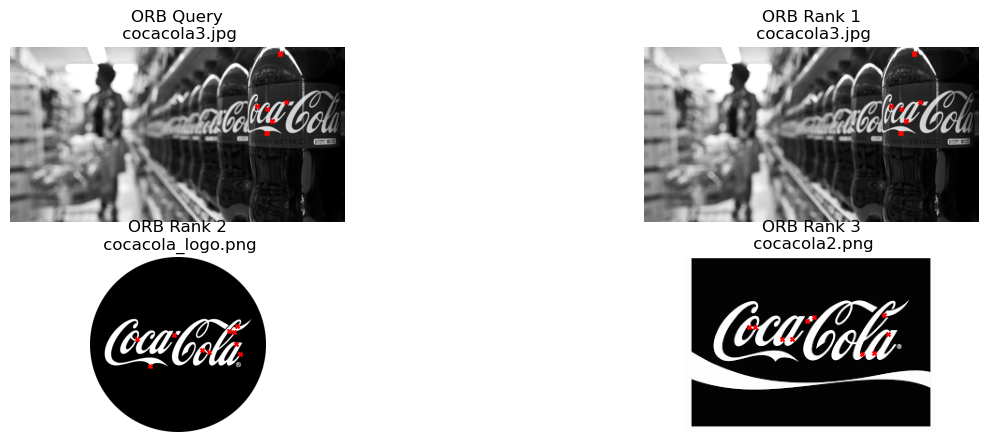

In [60]:
match_orb_images("resources_B/images/cocacola3.jpg",
                       n_keypoints=800, fast_threshold=0.08,
                       max_ratio=0.8, cross_check=False, plot_top=150)

## Hogwarts Boundary Bash

In this exercise you have to segment hogwarts.jpeg image with both Felzenszwalb and Quickshift algorithms on two different cases:

- Case 1: Apply Felzenszwalb and Quickshift directly on the RGB image.
- Case 2: Convert the image to Lab (rgb2lab) before segmentation.

The output should be a 2×2 grid with Top row = RGB (Felzenszwalb | Quickshift) and Bottom row = Lab (Felzenszwalb | Quickshift). Each subplot should show boundaries overlaid on the original image as shown below:


![Hogwarts](Hogwarts_Boundary_Bash_B.png)

En este ejercicio tienes que segmentar la imagen hogwarts.jpeg con los algoritmos **Felzenszwalb** y **Quickshift** en dos casos diferentes:

- **Caso 1:** Aplica Felzenszwalb y Quickshift directamente sobre la imagen RGB.
- **Caso 2:** Convierte la imagen a Lab (rgb2lab) antes de la segmentación.

La salida debe ser una cuadrícula de **2×2** con **fila superior = RGB (Felzenszwalb | Quickshift)** y **fila inferior = Lab (Felzenszwalb | Quickshift)**. Cada subgráfica debe mostrar los **bordes superpuestos** sobre la imagen original, como se muestra a continuación:

![Hogwarts](Hogwarts_Boundary_Bash_B.png)


In [69]:
# -----------------------------
# SLIC CONFIG
# -----------------------------
#    n_segments=350
#    compactness=10
#    sigma=1
#    start_label=1
# -----------------------------
# -----------------------------
# Quickshift CONFIG
# -----------------------------
#    kernel_size=3,
#    max_dist=6,
#    ratio=0.5
# -----------------------------

# Start here...




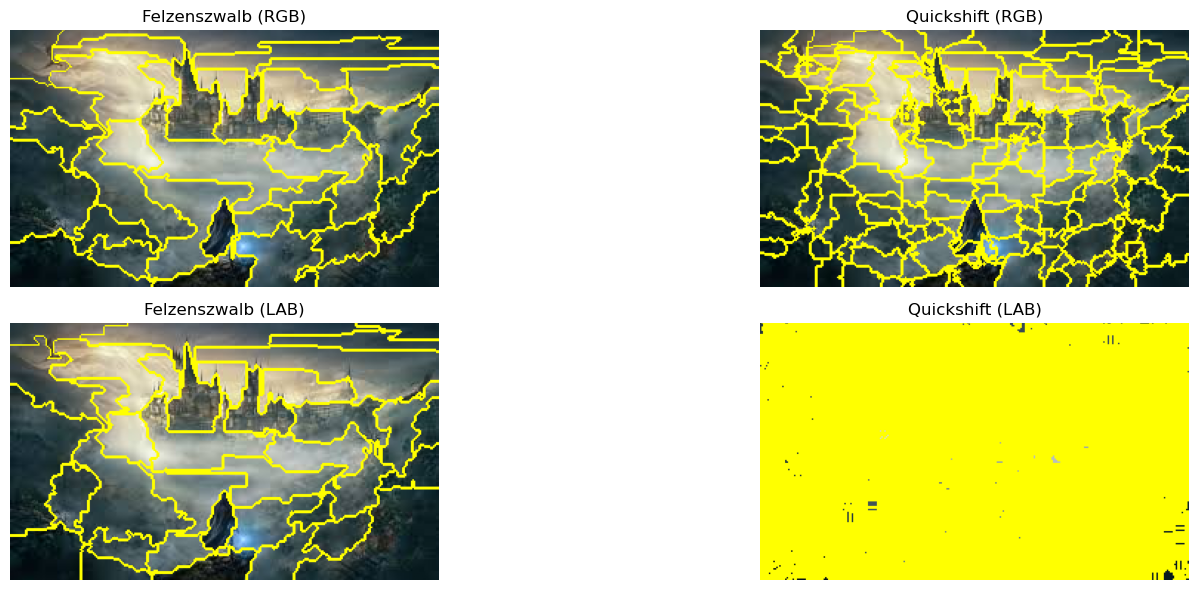

In [16]:
import numpy as np
from skimage import io, segmentation, transform, img_as_float, color

import matplotlib.pyplot as plt

# Crearemos una función para poder aplicar la segmentación de Felzenszwalb y poder mostrar el resultado
def explore_felzenszwalb(image_path):
    # Leemos la imagen
    image = io.imread(image_path)
    
    # Convertimos la imagen a float, ya que algunas funciones requieren este formato. 
    image_float_rgb = img_as_float(image)
    image_float_Lab = color.rgb2lab(image)

    # Haremos uso de un for para poder dibujar las imágenes 
    fig, axes = plt.subplots(2, 2, figsize=(18, 6))


    # Para cada lista de parámetros dada, aplicaremos la segmentación de Felzenszwalb 
    segments_rgb = segmentation.felzenszwalb(image_float_rgb, sigma=1, min_size=300)
    segments_lab = segmentation.felzenszwalb(image_float_Lab, sigma=1, min_size=300)
    segments_quickshift_rgb = segmentation.quickshift(image_float_rgb, kernel_size=3, max_dist=6, ratio=0.5)
    segments_quickshift_lab = segmentation.quickshift(image_float_Lab, kernel_size=3, max_dist=6, ratio=0.5)


    # Mostramos el resultado
    axes[0,0].imshow(segmentation.mark_boundaries(image_float_rgb, segments_rgb))
    axes[0,0].set_title("Felzenszwalb (RGB)")
    axes[0,0].axis('off')

    axes[1,0].imshow(segmentation.mark_boundaries(image_float_rgb, segments_lab))
    axes[1,0].set_title("Felzenszwalb (LAB)")
    axes[1,0].axis('off')
    
    axes[0,1].imshow(segmentation.mark_boundaries(image_float_rgb, segments_quickshift_rgb))
    axes[0,1].set_title("Quickshift (RGB)")
    axes[0,1].axis('off')

    axes[1,1].imshow(segmentation.mark_boundaries(image_float_rgb, segments_quickshift_lab))
    axes[1,1].set_title("Quickshift (LAB)")
    axes[1,1].axis('off')

    plt.tight_layout()
    plt.show()


# Llamamos a la función que hemos creado para mostrar el resultado de hacer la segmentación de Felzenszwalb para cada lista de parámetros indicada
explore_felzenszwalb('hogwarts.jpeg')

# Last Lap: The Face Pipeline [Extra Exercise]

This is the ***[Extra]*** exercise. If done correctly you will be able to increase your practical mark by 0,8 (out of the total 4 points) at best. **This is not part of the main exam!** Do it only if you feel like it and **after finishing the actual exam**.

If you reached this far, congratulations! Lets start with the exercise.

You are given a dataset of face images stored in a folder (e.g., `faces/`).  Build a pipeline that performs the following steps:

1. **Load the dataset**
   - Load all images from the folder.
   - Convert them to grayscale and resize to **64×64**.

2. **Fit PCA**
   - Fit a PCA model on \(X\) using **\(K = 10\)** principal components (you might need to apply "*flatten*").
   - Use a fixed random seed for reproducibility when applicable.

3. **Select one random face (reproducible)**
   - Choose one image index uniformly at random using a fixed seed.
   - Extract the selected face both as a vector \(x\) and as an image for display.

4. **Reconstruct with PCA and compute error**
   - Project the selected image vector \(x\) into PCA space and reconstruct it..
   - Compute the absolute per-pixel reconstruction error image.

5. **ORB feature detection**
   - Compute ORB keypoints (up to **1000** keypoints) on the selected face.
   - Visualize the **top 10** (at most) keypoints on the image.

6. **Quickshift segmentation**
   - Apply Quickshift superpixel segmentation to the selected face.
   - If required, convert the grayscale image to RGB before running Quickshift.
   - Visualize the segmentation boundaries overlaid on the image.

7. **Visualization**
   - Create a **1×4** figure showing, in order:
     1. Original face image  
     2. Absolute PCA reconstruction error image  
     3. ORB keypoints visualization (top 10)  
     4. Quickshift boundaries overlay  
   - Add appropriate titles and hide axes.

   Final results should look similar to the following example:

![Hogwarts](extra_exercise.png)
   

Este es el ejercicio ***[Extra]***. Si lo realizas correctamente, podrás aumentar tu nota de prácticas en **0,8** (de un total de 4 puntos) como máximo. **¡Esto no forma parte del examen principal!** Hazlo solo si te apetece y **después de terminar el examen real**.

Si has llegado hasta aquí, ¡enhorabuena! Empecemos con el ejercicio.

Se te proporciona un conjunto de imágenes de rostros almacenadas en una carpeta (p. ej., `faces/`). Construye una pipeline que realice los siguientes pasos:

1. **Cargar el dataset**
   - Carga todas las imágenes de la carpeta.
   - Conviértelas a escala de grises y redimensiona a **64×64**.

2. **Entrena PCA**
   - Entrena un modelo PCA sobre \(X\) usando **\(K = 10\)** componentes principales (puede que necesites aplicar "*flatten*").
   - Usa una semilla aleatoria fija para reproducibilidad cuando aplique.

3. **Seleccionar un rostro aleatorio (reproducible)**
   - Elige un índice de imagen de manera uniforme al azar usando una semilla fija.
   - Extrae el rostro seleccionado tanto como vector \(x\) como en forma de imagen para mostrarlo.

4. **Reconstruir con PCA y calcular el error**
   - Proyecta el vector de la imagen seleccionada \(x\) en el espacio PCA y reconstrúyelo.
   - Calcula la imagen de error absoluto de reconstrucción por píxel.

5. **Detección de características ORB**
   - Calcula puntos clave ORB (hasta **1000** puntos clave) sobre el rostro seleccionado.
   - Visualiza los **top 10** (como máximo) puntos clave sobre la imagen.

6. **Segmentación Quickshift**
   - Aplica la segmentación en superpíxeles Quickshift al rostro seleccionado.
   - Si es necesario, convierte la imagen en escala de grises a RGB antes de ejecutar Quickshift.
   - Visualiza los bordes de la segmentación superpuestos sobre la imagen.

7. **Visualización**
   - Crea una figura de **1×4** mostrando, en este orden:
     1. Imagen original del rostro  
     2. Imagen del error absoluto de reconstrucción PCA  
     3. Visualización de puntos clave ORB (top 10)  
     4. Superposición de bordes de Quickshift  
   - Añade títulos apropiados y oculta los ejes.

Los resultados finales deberían verse similares al siguiente ejemplo:

![Hogwarts](extra_exercise.png)


In [ ]:
# This is the last one, good luck!!